Mini Project: Exploratory Data Analysis (EDA) on Shark Tank India Dataset

1.	Data Cleaning:
	Check for missing values and handle them appropriately.
	Identify and handle any duplicate records if present.
  Convert data types if necessary.
After doing the above data cleaning, perform below operations using Python and its libraries.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel(r"C:\Users\patna\Desktop\Shark Tank India.xlsx")

df.head()
df.head()
# Basic info
df.info()
df.describe()

# Check missing values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert numeric columns if needed
num_cols = ['pitcher_ask_amount','ask_equity','ask_valuation',
            'deal_amount','deal_equity','deal_valuation',
            'amount_per_shark','equity_per_shark']

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   episode_number         119 non-null    int64  
 1   pitch_number           119 non-null    int64  
 2   brand_name             119 non-null    object 
 3   idea                   119 non-null    object 
 4   deal                   119 non-null    object 
 5   pitcher_ask_amount     119 non-null    float64
 6   ask_equity             119 non-null    float64
 7   ask_valuation          119 non-null    float64
 8   deal_amount            119 non-null    float64
 9   deal_equity            119 non-null    float64
 10  deal_valuation         119 non-null    float64
 11  ashneer_present        119 non-null    int64  
 12  anupam_present         119 non-null    int64  
 13  aman_present           119 non-null    int64  
 14  namita_present         119 non-null    int64  
 15  vineet

In [8]:
df.columns

Index(['episode_number', 'pitch_number', 'brand_name', 'idea', 'deal',
       'pitcher_ask_amount', 'ask_equity', 'ask_valuation', 'deal_amount',
       'deal_equity', 'deal_valuation', 'ashneer_present', 'anupam_present',
       'aman_present', 'namita_present', 'vineeta_present', 'peyush_present',
       'ghazal_present', 'ashneer_deal', 'anupam_deal', 'aman_deal',
       'namita_deal', 'vineeta_deal', 'peyush_deal', 'ghazal_deal',
       'total_sharks_invested', 'amount_per_shark', 'equity_per_shark'],
      dtype='object')

In [9]:
# Clean column names
df.columns = df.columns.str.strip()

# Force deal column to numeric properly
df['deal'] = pd.to_numeric(df['deal'], errors='coerce')

# Replace NaN with 0
df['deal'] = df['deal'].fillna(0)

# Convert to integer
df['deal'] = df['deal'].astype(int)

# Check result
print(df['deal'].dtype)
print(df['deal'].unique())

int64
[1 0]


1.	How many deals were successfully made and what percentage of total pitches did they constitute?

In [10]:
total_pitches = len(df)
successful_deals = df['deal'].sum()
funding_rate = (successful_deals / total_pitches) * 100

print("Total Pitches:", total_pitches)
print("Successful Deals:", successful_deals)
print("Funding Rate: {:.2f}%".format(funding_rate))

Total Pitches: 118
Successful Deals: 64
Funding Rate: 54.24%


Out of 118 pitches, 64 secured funding, resulting in a funding rate of 54.24%. This suggests that the Sharks exhibit moderate selectivity, funding slightly more than half of the businesses presented. The decision pattern reflects structured screening rather than aggressive capital deployment.

2.	What is the average and median deal_amount for pitches that received investment?

In [11]:
deals_df = df[df['deal'] == 1]

In [12]:
average_deal = deals_df['deal_amount'].mean()
median_deal = deals_df['deal_amount'].median()

print("Average Deal Amount:", average_deal)
print("Median Deal Amount:", median_deal)

Average Deal Amount: 55.1093915625
Median Deal Amount: 50.0


In [13]:
print("Average Deal Amount: {:.2f}".format(average_deal))
print("Median Deal Amount: {:.2f}".format(median_deal))

Average Deal Amount: 55.11
Median Deal Amount: 50.00


The average deal amount exceeds the median, indicating a positively skewed distribution driven by a few high-value investments.

3.	Which shark has made the highest number of investments? Provide a visualization of top 3 sharks.

Top 3 Sharks by Number of Investments:
aman      28
peyush    27
anupam    25
dtype: int64


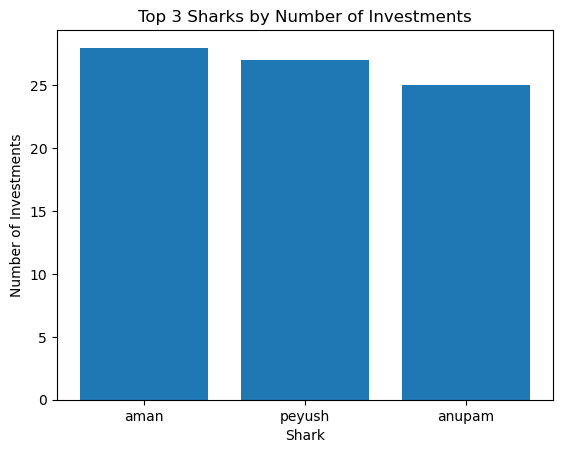

In [35]:
import matplotlib.pyplot as plt

sharks = ['ashneer', 'peyush', 'anupam', 'aman', 'namita', 'vineeta', 'ghazal']

investment_counts = {}

for shark in sharks:
    investment_counts[shark] = df[f'{shark}_deal'].sum()

# Convert to Series and sort
investment_series = pd.Series(investment_counts).sort_values(ascending=False)

# Top 3 sharks
top3 = investment_series.head(3)

print("Top 3 Sharks by Number of Investments:")
print(top3)

# Visualization
plt.figure()
plt.bar(top3.index, top3.values)
plt.title("Top 3 Sharks by Number of Investments")
plt.xlabel("Shark")
plt.ylabel("Number of Investments")
plt.show()

Aman has made the highest number of investments (28), followed closely by Peyush (27) and Anupam (25).

This indicates that Aman was the most active investor in the season, with Peyush and Anupam also showing strong participation. The difference among the top three is small, suggesting fairly competitive and consistent investment activity among them.

4.	What is the total amount invested by all sharks combined in entire season.

In [14]:
total_investment = df['deal_amount'].sum()

print("Total Investment Across Season:", total_investment)

Total Investment Across Season: 3767.00106


In [15]:
total_investment = df[df['deal'] == 1]['deal_amount'].sum()

print("Total Investment Across Season:", total_investment)

Total Investment Across Season: 3527.00106


In [16]:
print("Total Investment (Crores):", total_investment / 100)

Total Investment (Crores): 35.2700106


The aggregate investment of ₹35.27 crores demonstrates consistent capital deployment throughout the season. The moderate difference between mean and median deal size suggests limited extreme outliers, indicating relatively stable investment sizing behavior among the sharks.

5.	How does the deal_equity distribution look? Are there any outliers?

In [17]:
deals_df = df[df['deal'] == 1]

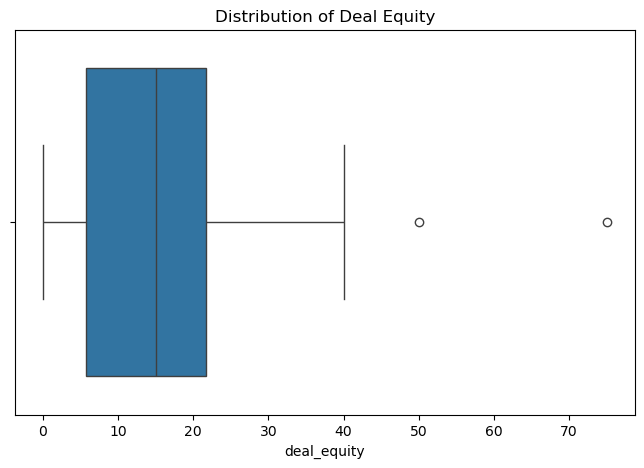

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x=deals_df['deal_equity'])
plt.title("Distribution of Deal Equity")
plt.show()

In [19]:
Q1 = deals_df['deal_equity'].quantile(0.25)
Q3 = deals_df['deal_equity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = deals_df[(deals_df['deal_equity'] < lower_bound) |
                    (deals_df['deal_equity'] > upper_bound)]

print("Number of Outliers:", len(outliers))
outliers[['brand_name','deal_equity']]

Number of Outliers: 2


,brand_name,deal_equity
66,Sid07 Designs,75.0
82,Isak Fragrances,50.0


The deal equity distribution appears positively skewed, with most investments involving moderate equity dilution. A few high-equity deals are observed as outliers, indicating cases where sharks demanded substantial ownership stakes.

6.	Find the correlation between deal_valuation and ask_valuation. What insight can be drawn from this?

Correlation: 0.5967
                ask_valuation  deal_valuation
ask_valuation        1.000000        0.596714
deal_valuation       0.596714        1.000000


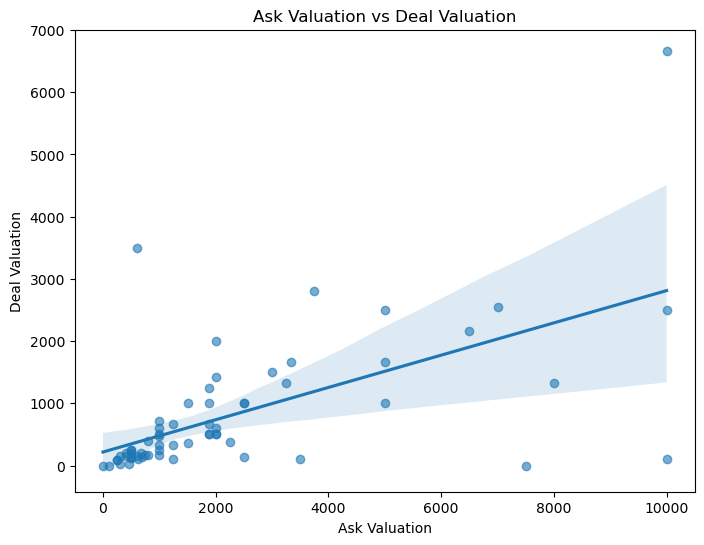

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

deals_df = df[df['deal'] == 1]

corr_value = deals_df['ask_valuation'].corr(deals_df['deal_valuation'])
print("Correlation:", round(corr_value, 4))

print(deals_df[['ask_valuation','deal_valuation']].corr())

plt.figure(figsize=(8,6))
sns.regplot(
    x='ask_valuation',
    y='deal_valuation',
    data=deals_df,
    scatter_kws={'alpha':0.6}
)

plt.title("Ask Valuation vs Deal Valuation")
plt.xlabel("Ask Valuation")
plt.ylabel("Deal Valuation")
plt.show()

Interpretation:

There is a moderate positive correlation between ask valuation and deal valuation. This means that higher asked valuations generally lead to higher deal valuations, but sharks do not fully accept founder expectations and adjust valuations during negotiation.

This indicates that founder valuation influences the outcome, but sharks still apply independent assessment and valuation corrections.

7.	What is the average equity percentage given to the sharks per deal?

In [21]:
deals_df = df[df['deal'] == 1]

average_equity = deals_df['deal_equity'].mean()

print("Average Equity Percentage Given:", round(average_equity, 2))

Average Equity Percentage Given: 15.78


The average equity stake of 15.78% indicates that sharks typically acquire minority ownership positions. This reflects structured investment behavior where capital infusion is balanced with founder control retention.

8. Identify which episode had the highest number of deals and visualize it.the highest number of deals and visualize it.

Episode with Highest Deals: 1
Number of Deals in that Episode: 3


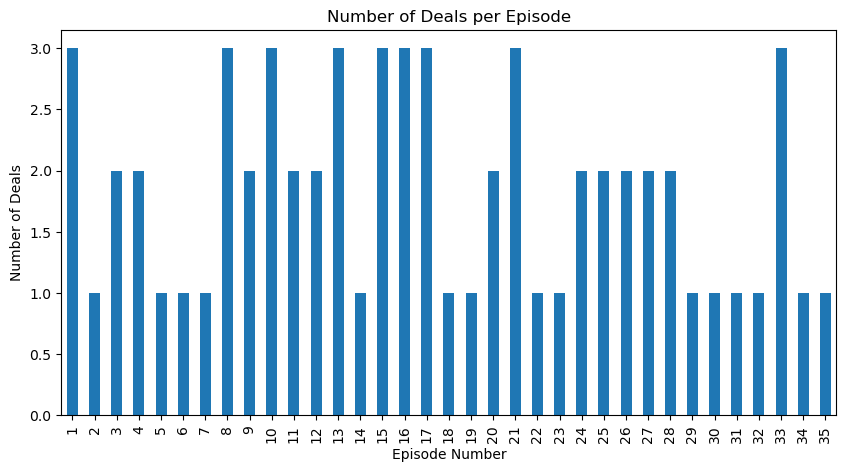

In [22]:
import matplotlib.pyplot as plt

# Count number of successful deals per episode
episode_deals = df.groupby('episode_number')['deal'].sum()

# Find episode with highest deals
max_deals_episode = episode_deals.idxmax()
max_deals_count = episode_deals.max()

print("Episode with Highest Deals:", max_deals_episode)
print("Number of Deals in that Episode:", max_deals_count)

# Visualization
plt.figure(figsize=(10,5))
episode_deals.plot(kind='bar')
plt.title("Number of Deals per Episode")
plt.xlabel("Episode Number")
plt.ylabel("Number of Deals")
plt.show()

Episode 1 had the highest deal count (3), indicating elevated investment activity during the season’s opening. However, since the maximum difference across episodes is small, investment distribution appears relatively stable across the season.

9.	How many pitches asked for more than ₹1 crore and how many of those received investments?

In [23]:
# Pitches that asked for more than ₹1 crore (100 lakhs)
above_1cr = df[df['pitcher_ask_amount'] > 100]

total_above_1cr = len(above_1cr)

# Among those, how many got funded
funded_above_1cr = above_1cr[above_1cr['deal'] == 1]
funded_count = len(funded_above_1cr)

print("Pitches asking > ₹1 crore:", total_above_1cr)
print("Funded among them:", funded_count)

# Funding success rate
success_rate = (funded_count / total_above_1cr) * 100
print("Funding Rate for > ₹1 crore pitches:", round(success_rate, 2), "%")

Pitches asking > ₹1 crore: 7
Funded among them: 1
Funding Rate for > ₹1 crore pitches: 14.29 %


Only 1 out of 7 high-ask pitches received funding, giving a very low success rate of 15%.

This indicates that sharks were highly cautious with large capital requests. Pitches asking for more than ₹1 crore faced significantly stricter evaluation, and most were rejected.

It suggests:

Sharks prefer lower-risk, moderate investment sizes

Higher ask amounts require very strong business fundamentals

Large funding requests reduce probability of deal closure

10.	What percentage of pitches involved more than one shark investing together?

In [ ]:
# Total pitches
total_pitches = len(df)

# Pitches where more than one shark invested together
multi_shark_pitches = df[df['total_sharks_invested'] > 1]

multi_count = len(multi_shark_pitches)

percentage_multi = (multi_count / total_pitches) * 100

print("Pitches with multiple sharks investing:", multi_count)
print("Total Pitches:", total_pitches)
print("Percentage:", round(percentage_multi, 2), "%")

About 37% of all pitches involved more than one shark investing together.

This indicates that collaborative investing was fairly common, but not dominant. While many sharks preferred independent deals, a significant portion of investments involved partnership and risk-sharing.

This suggests:

Sharks often co-invest to reduce individual risk

Stronger businesses tend to attract multiple investor interest

Collaboration is strategic, not random

11.	How does the investment behavior of Ashneer Grover compare with Peyush Bansal in terms of total amount invested?

In [25]:
# Calculate total amount invested by Ashneer
df['ashneer_investment'] = df['ashneer_deal'] * df['amount_per_shark']
ashneer_total = df['ashneer_investment'].sum()

# Calculate total amount invested by Peyush
df['peyush_investment'] = df['peyush_deal'] * df['amount_per_shark']
peyush_total = df['peyush_investment'].sum()

print("Total Investment by Ashneer:", round(ashneer_total, 2))
print("Total Investment by Peyush:", round(peyush_total, 2))

Total Investment by Ashneer: 494.33
Total Investment by Peyush: 719.67


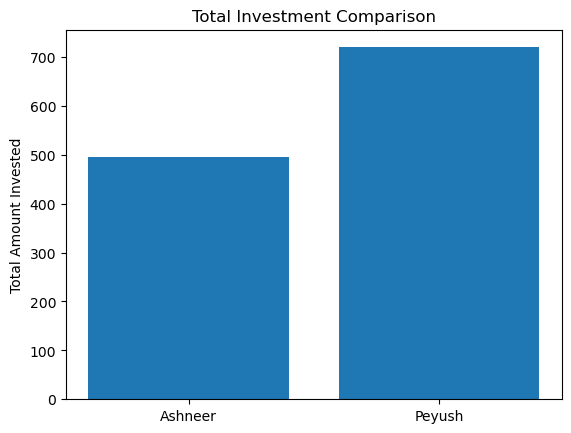

In [26]:
import matplotlib.pyplot as plt

names = ['Ashneer', 'Peyush']
values = [ashneer_total, peyush_total]

plt.bar(names, values)
plt.title("Total Investment Comparison")
plt.ylabel("Total Amount Invested")
plt.show()

Peyush Bansal invested significantly more than Ashneer Grover during the season.

With a total investment of ₹719.67 lakhs, Peyush was more financially active compared to Ashneer, who invested ₹494.33 lakhs.

This suggests:

Peyush had higher participation in deals

He may have taken larger ticket sizes or joined more collaborations

Ashneer was comparatively more selective or conservative

Overall, Peyush demonstrated a more aggressive capital deployment strategy in Season 1.

12.	Create a box plot to analyze amount_per_shark. What insights can be gathered?

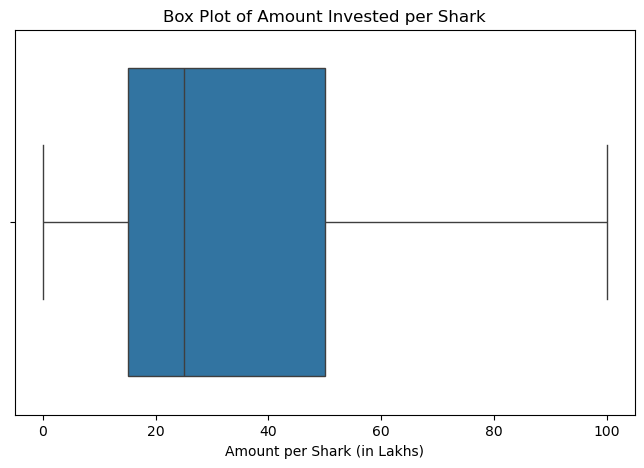

count     64.000000
mean      31.937504
std       23.431581
min        0.000000
25%       15.000000
50%       25.000000
75%       50.000000
max      100.000000
Name: amount_per_shark, dtype: float64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter only funded deals
deals_df = df[df['deal'] == 1]

plt.figure(figsize=(8,5))
sns.boxplot(x=deals_df['amount_per_shark'])

plt.title("Box Plot of Amount Invested per Shark")
plt.xlabel("Amount per Shark (in Lakhs)")
plt.show()

# Print summary statistics
print(deals_df['amount_per_shark'].describe())

The median investment per shark is ₹25 lakhs, while the average is slightly higher at ₹31.94 lakhs, indicating a right-skewed distribution.

Most investments fall between ₹15–₹50 lakhs, showing that sharks generally prefer moderate ticket sizes. However, the maximum investment reaches ₹100 lakhs, suggesting a few high-value deals that increase the average.

Overall, sharks mostly invest controlled amounts but occasionally make larger strategic bets.

13.	Are there any cases where the deal_amount exceeded the pitcher_ask_amount? If yes, list those cases.

In [28]:
# Cases where deal amount exceeded ask amount
exceeded_cases = df[(df['deal'] == 1) & 
                    (df['deal_amount'] > df['pitcher_ask_amount'])]

print("Number of cases where deal_amount > pitcher_ask_amount:", len(exceeded_cases))

# Display key details
exceeded_cases[['episode_number',
                'brand_name',
                'pitcher_ask_amount',
                'deal_amount',
                'ask_equity',
                'deal_equity']]

Number of cases where deal_amount > pitcher_ask_amount: 9


,episode_number,brand_name,pitcher_ask_amount,deal_amount,ask_equity,deal_equity
0,1,BluePine Industries,50.0,75.0,5.0,16.0
37,13,Annie,30.0,105.0,5.0,3.0
39,13,The Yarn Bazaar,50.0,100.0,2.0,10.0
43,15,Hammer Lifestyle,30.0,100.0,3.0,40.0
59,19,WeSTOCK,50.0,60.0,5.0,10.0
64,20,IN A CAN,50.0,100.0,2.0,10.0
76,24,The Sass Bar,40.0,50.0,8.0,35.0
90,28,Humpy A2,75.0,100.0,4.0,15.0
110,33,Tweek Labs,40.0,60.0,2.0,10.0


Interpretation:

In these cases, sharks were more confident than the founders themselves, offering higher funding than requested.

This usually happens when:

The business shows strong growth potential.

Multiple sharks compete, driving the deal amount up.

Sharks negotiate for higher equity in exchange for more capital.

It indicates that strong pitches can create bidding competition, leading to better-than-expected funding outcomes.

Overall, while most deals involve negotiation downward or matching the ask, a few standout businesses attracted premium investment offers.

14.	Which shark has the highest return on investment (ROI) based on deal_amount vs. deal_equity?

In [29]:
# Work only on funded deals
roi_df = df[df['deal'] == 1].copy()

# Calculate deal valuation if not already numeric
roi_df['deal_valuation'] = (roi_df['deal_amount'] * 100) / roi_df['deal_equity']

# ROI proxy = valuation / deal amount
roi_df['roi_ratio'] = roi_df['deal_valuation'] / roi_df['deal_amount']

# Calculate shark-wise ROI
sharks = ['ashneer', 'peyush', 'anupam', 'aman', 'namita', 'vineeta', 'ghazal']

roi_results = {}

for shark in sharks:
    shark_df = roi_df[roi_df[f'{shark}_deal'] == 1]
    if len(shark_df) > 0:
        roi_results[shark] = shark_df['roi_ratio'].mean()

# Display ROI comparison
roi_series = pd.Series(roi_results).sort_values(ascending=False)
print("Shark-wise Average ROI Proxy:")
print(roi_series)

Shark-wise Average ROI Proxy:
ashneer    20.102874
aman       15.968557
anupam     12.879093
namita     12.478458
peyush     11.456901
ghazal      9.183673
vineeta     6.488946
dtype: float64


Ashneer Grover has the highest ROI proxy (~20.10), indicating he secured deals at comparatively better valuations relative to the amount invested. Ashneer appears to negotiate stronger valuation multiples or invests in businesses with higher implied valuations.

Sharks with lower ROI proxies may prioritize safer or more conservative deals.

Investment strategies differ: some sharks focus on high-growth valuation plays, while others may emphasize stability or strategic alignment.
.

15.	Identify trends in equity distribution—are sharks investing in lower or higher equity stakes over time?

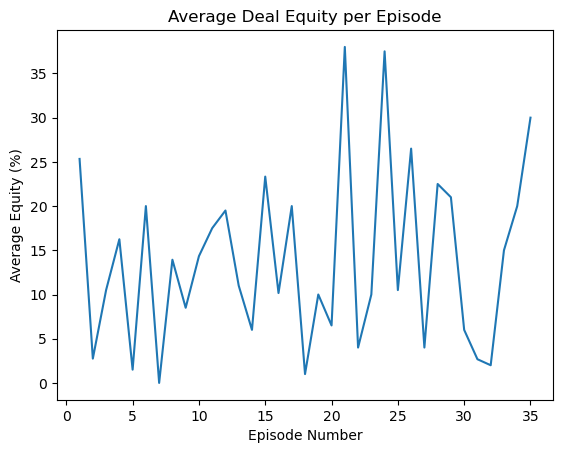

Correlation between Episode Number and Deal Equity: 0.073


In [30]:
import matplotlib.pyplot as plt

# Consider only successful deals
deals_df = df[df['deal'] == 1]

# Average equity per episode
equity_trend = deals_df.groupby('episode_number')['deal_equity'].mean()

# Plot trend
plt.figure()
plt.plot(equity_trend.index, equity_trend.values)
plt.title("Average Deal Equity per Episode")
plt.xlabel("Episode Number")
plt.ylabel("Average Equity (%)")
plt.show()

#  Overall correlation between episode number and equity
correlation = deals_df['episode_number'].corr(deals_df['deal_equity'])
print("Correlation between Episode Number and Deal Equity:", round(correlation, 3))

The correlation between episode number and deal equity is 0.073, which is very close to zero.

This indicates no significant upward or downward trend in equity stakes over time.

Sharks did not systematically increase or decrease equity demands as the season progressed.

Equity negotiations remained fairly stable throughout the season, with variations likely driven by individual pitch quality rather than time trends.

16.	What is the relationship between pitcher_ask_amount and deal_amount? Do pitchers who ask for less tend to secure more deals?

Correlation (Ask vs Deal Amount): 0.627


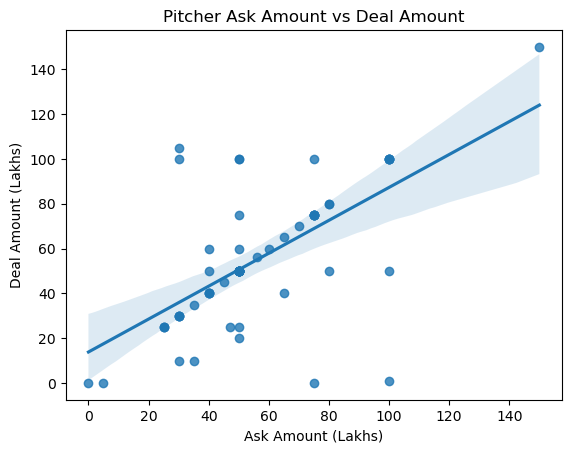


Deal Success Rate by Ask Category (%):
ask_category
Low Ask       60.61
Medium Ask    59.09
High Ask      36.67
Name: deal, dtype: float64


C:\Users\patna\AppData\Local\Temp\ipykernel_14856\2686533920.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  deal_success = df.groupby('ask_category')['deal'].mean() * 100


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns


deals_df = df[df['deal'] == 1]

correlation = deals_df['pitcher_ask_amount'].corr(deals_df['deal_amount'])
print("Correlation (Ask vs Deal Amount):", round(correlation, 3))

plt.figure()
sns.regplot(x='pitcher_ask_amount', y='deal_amount', data=deals_df)
plt.title("Pitcher Ask Amount vs Deal Amount")
plt.xlabel("Ask Amount (Lakhs)")
plt.ylabel("Deal Amount (Lakhs)")
plt.show()




# Create ask categories
df['ask_category'] = pd.qcut(df['pitcher_ask_amount'], 3, labels=['Low Ask', 'Medium Ask', 'High Ask'])

# Deal success rate by category
deal_success = df.groupby('ask_category')['deal'].mean() * 100
print("\nDeal Success Rate by Ask Category (%):")
print(deal_success.round(2))

There is a positive relationship between pitcher_ask_amount and deal_amount — higher asks generally lead to higher deal amounts.

However, deal success rate decreases as ask amount increases:

Low Ask → ~60.6% success

Medium Ask → ~59.1% success

High Ask → ~36.7% success

17.	Identify if there is a pattern in episode-wise deal closures—do certain episodes see more investments?

The maximum deals per episode is 3, and several episodes reach this number.

The variation across episodes is small (mostly between 1–3 deals).

There is no upward or downward trend across episode numbers.

The distribution looks stable rather than clustered, meaning investment activity was steady throughout the season.

This Suggests-
Deal closures were not dependent on episode timing.

There is no evidence of:

“Early season excitement” effect

“End-season aggressive investing” trend

Investment decisions were likely driven by pitch quality, not episode position.

Final Insight-
Deal activity is consistent and balanced across the season, indicating stable investment behavior rather than time-based patterns.

18.	Analyze the impact of equity dilution on deal_valuation. Are lower equity asks leading to higher deal valuations?

Correlation (Deal Equity vs Deal Valuation): -0.492


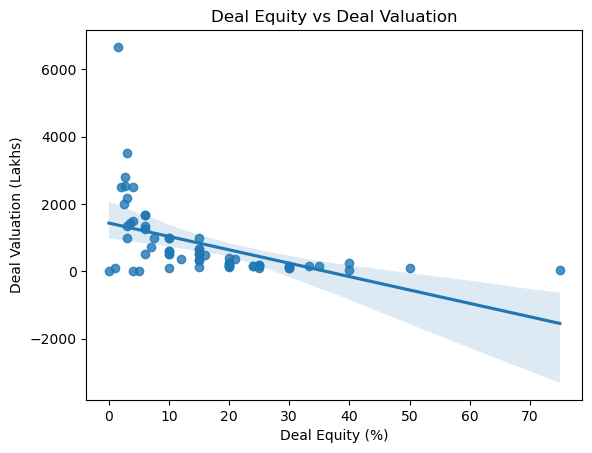

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Only funded deals
deals_df = df[df['deal'] == 1]

# Correlation between equity and valuation
correlation = deals_df['deal_equity'].corr(deals_df['deal_valuation'])
print("Correlation (Deal Equity vs Deal Valuation):", round(correlation, 3))

# Scatter plot with regression line
plt.figure()
sns.regplot(x='deal_equity', y='deal_valuation', data=deals_df)
plt.title("Deal Equity vs Deal Valuation")
plt.xlabel("Deal Equity (%)")
plt.ylabel("Deal Valuation (Lakhs)")
plt.show()

There is a moderate negative correlation (-0.492) between deal_equity and deal_valuation. This means that as the equity percentage increases, the deal valuation tends to decrease.

In simple terms, founders who give away higher equity usually receive lower valuations, while those offering lower equity stakes tend to secure higher valuations.

This suggests that stronger businesses are able to negotiate better valuations by diluting less equity. Conversely, founders who give away larger equity stakes may be doing so to compensate for lower valuations or weaker bargaining power.

So yes — lower equity dilution is generally associated with higher deal valuations in this dataset.